<a href="https://www.kaggle.com/code/sonawanelalitsunil/salary-data-eda-97-65?scriptVersionId=265403013" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-data/Salary_Data.csv


## Title: 
Salary Data

## Description:
This dataset contains information related to employee salaries, which can be used to analyze compensation trends, compare pay across roles, industries, or locations, and build predictive models. It may include variables such as job titles, departments, years of experience, education level, company size, and geographic location. The dataset is suitable for exploring patterns in employee compensation, identifying factors influencing salaries, and supporting HR analytics or workforce planning.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/salary-data/Salary_Data.csv")

In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [8]:
df.duplicated().sum()

4912

In [9]:
df.describe().loc[['min', 'max', 'mean']]

,Age,Years of Experience,Salary
min,21.000000,0.000000,350.000000
max,62.000000,34.000000,250000.000000
mean,33.620859,8.094687,115326.964771


In [10]:
df.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

In [11]:
df.shape

(6704, 6)

In [12]:
df.nunique()

Age                     41
Gender                   3
Education Level          7
Job Title              193
Years of Experience     37
Salary                 444
dtype: int64

In [13]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

## Data visualizations

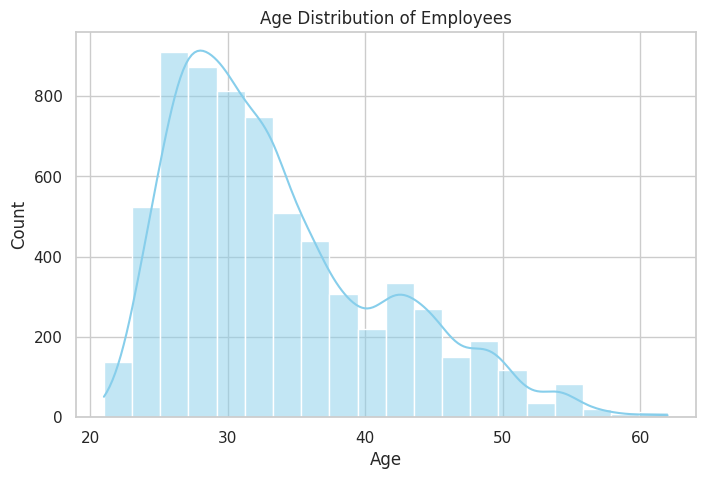

In [14]:
# Set visualization style
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10,6)

# 1. Distribution of Age
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

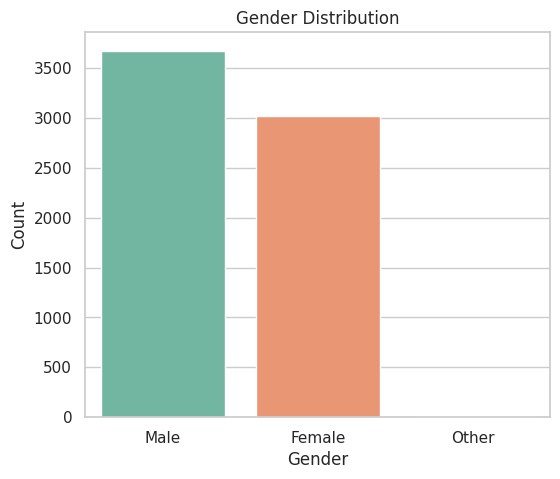

In [15]:
# 2. Gender Countplot
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df, palette="Set2")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

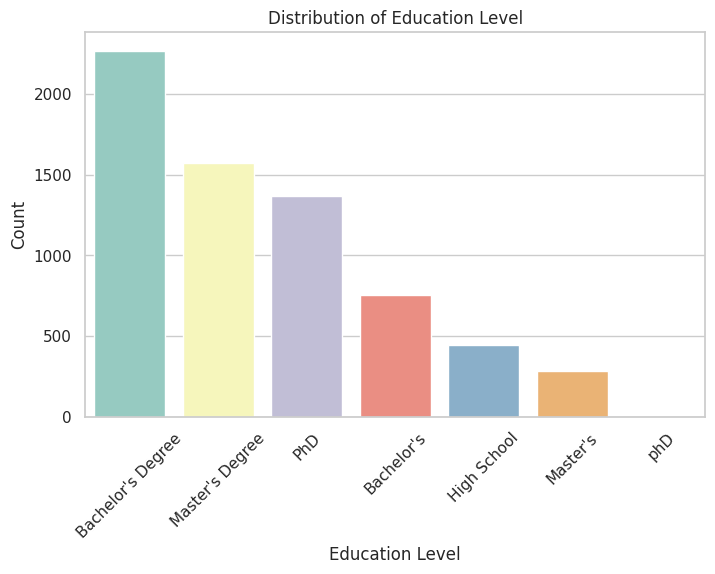

In [16]:
# 3. Education Level vs Count
plt.figure(figsize=(8,5))
sns.countplot(x='Education Level', data=df, palette="Set3", order=df['Education Level'].value_counts().index)
plt.title("Distribution of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

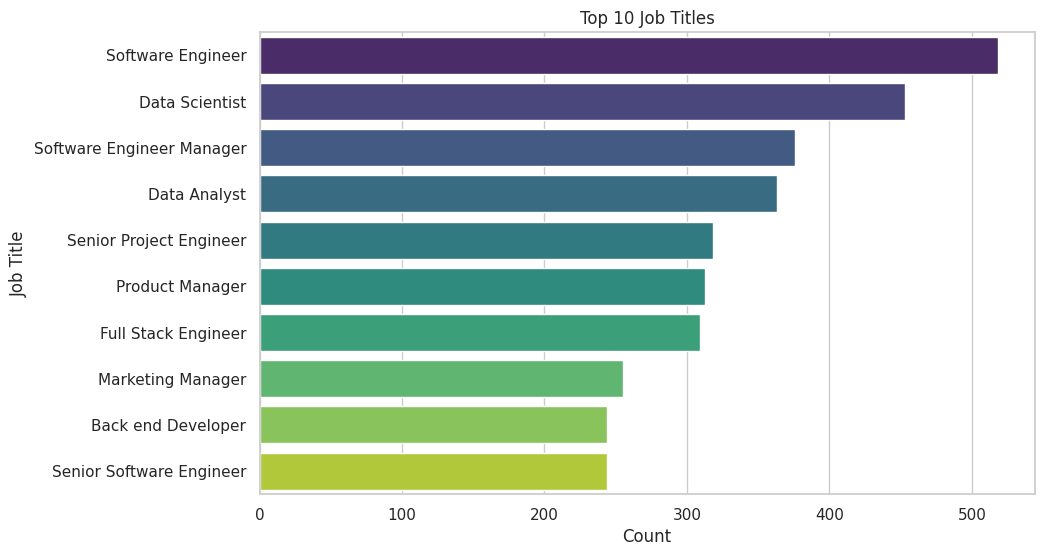

In [17]:
# 4. Job Title Distribution (Top 10)
plt.figure(figsize=(10,6))
top_jobs = df['Job Title'].value_counts().nlargest(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="viridis")
plt.title("Top 10 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

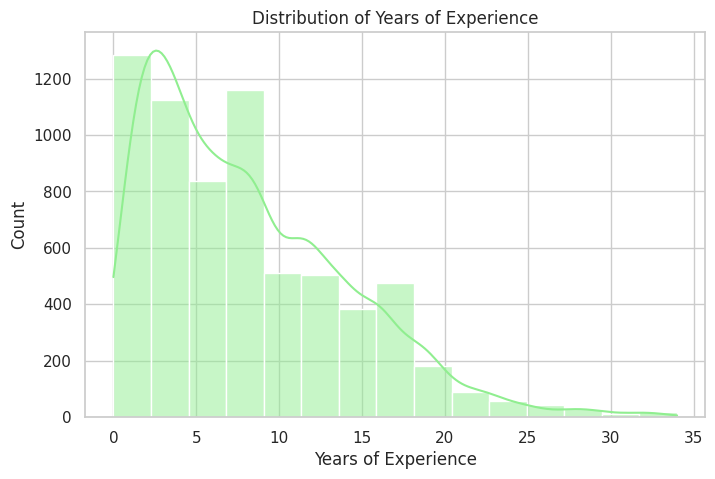

In [18]:
# 5. Years of Experience Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Years of Experience'], bins=15, kde=True, color="lightgreen")
plt.title("Distribution of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.show()

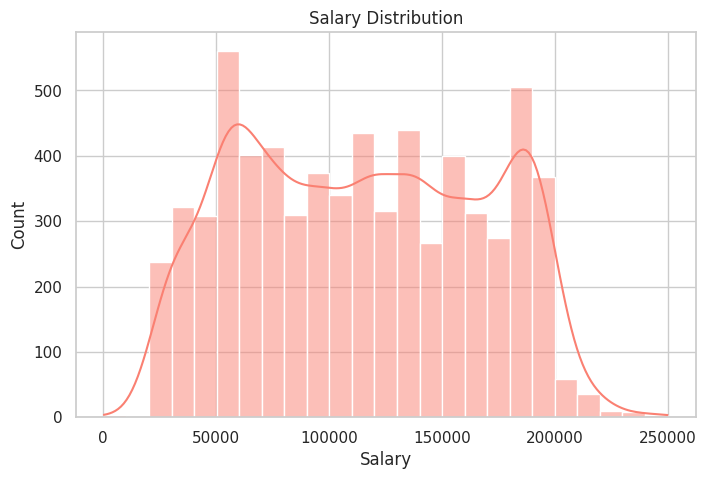

In [19]:
# 6. Salary Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], bins=25, kde=True, color="salmon")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

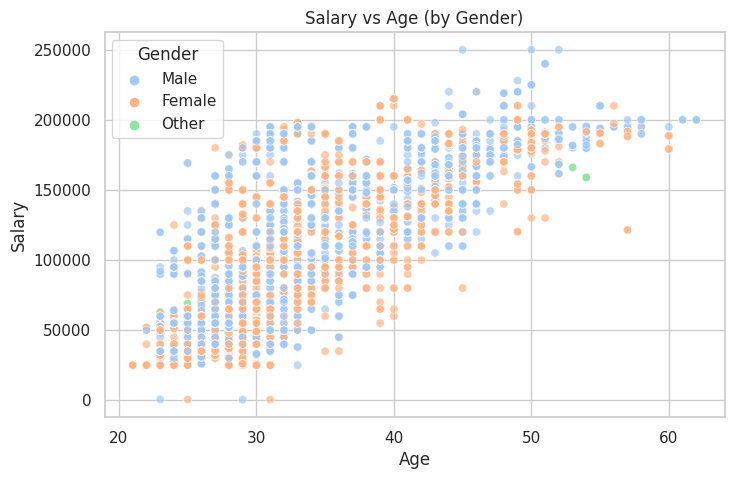

In [20]:
# 7. Salary vs Age
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Salary", data=df, hue="Gender", alpha=0.7)
plt.title("Salary vs Age (by Gender)")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

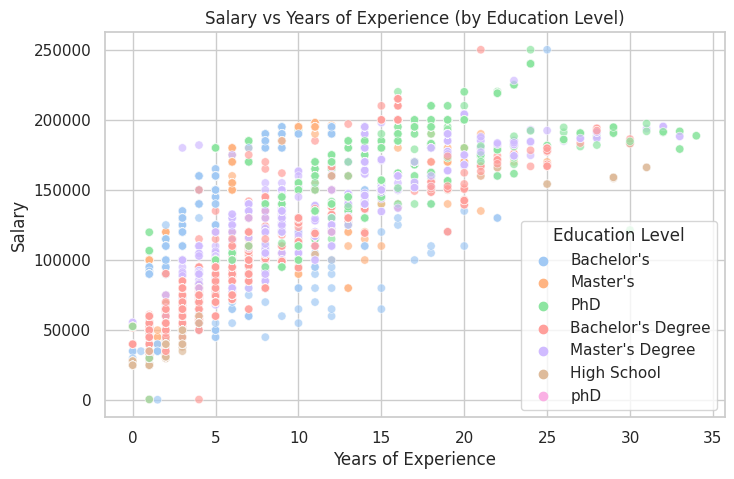

In [21]:
# 8. Salary vs Years of Experience
plt.figure(figsize=(8,5))
sns.scatterplot(x="Years of Experience", y="Salary", data=df, hue="Education Level", alpha=0.7)
plt.title("Salary vs Years of Experience (by Education Level)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

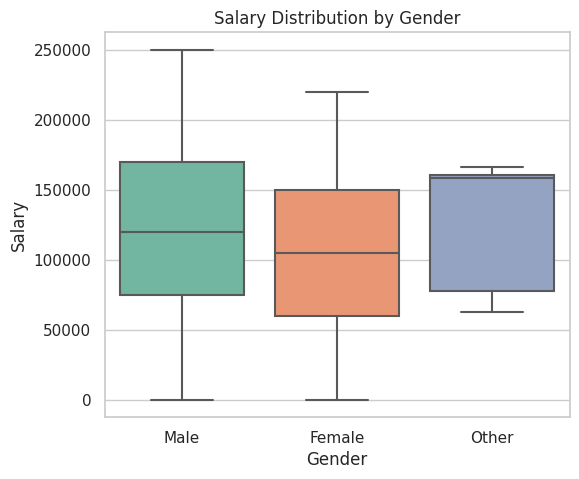

In [22]:
# 9. Salary by Gender
plt.figure(figsize=(6,5))
sns.boxplot(x="Gender", y="Salary", data=df, palette="Set2")
plt.title("Salary Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Salary")
plt.show()

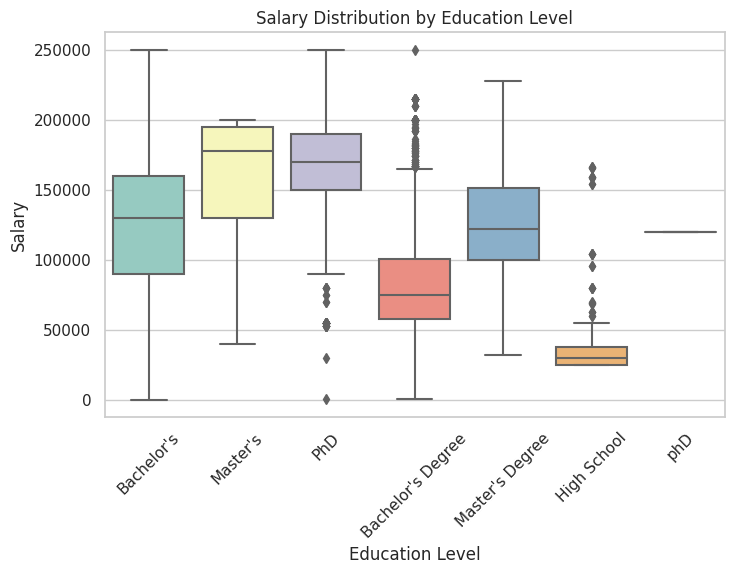

In [23]:
# 10. Salary by Education Level
plt.figure(figsize=(8,5))
sns.boxplot(x="Education Level", y="Salary", data=df, palette="Set3")
plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

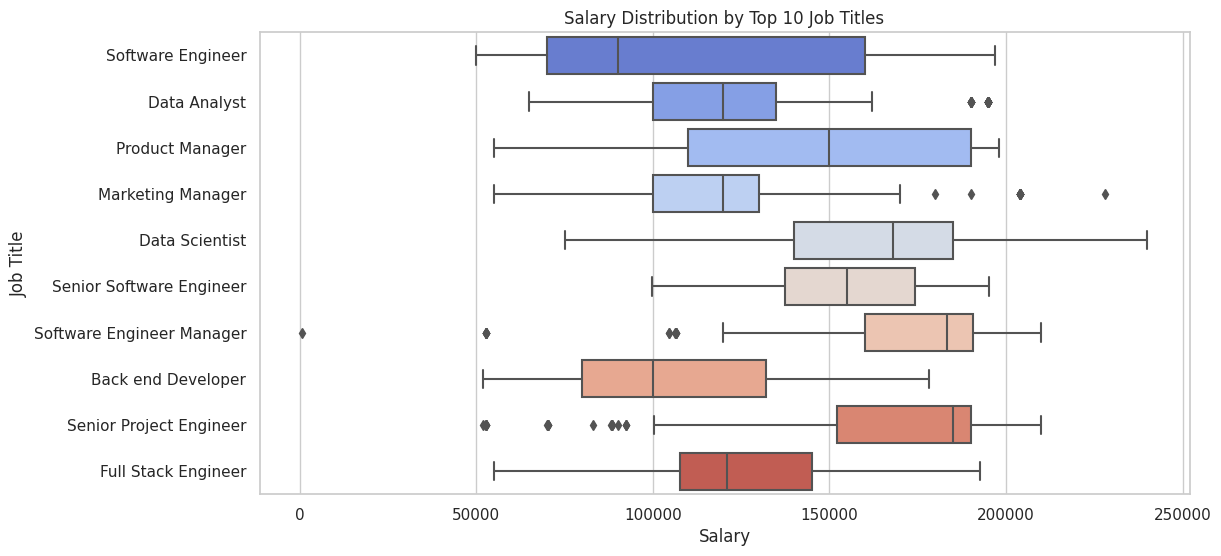

In [24]:
# 11. Salary by Job Title (Top 10)
plt.figure(figsize=(12,6))
top_jobs_salary = df[df['Job Title'].isin(top_jobs.index)]
sns.boxplot(x="Salary", y="Job Title", data=top_jobs_salary, palette="coolwarm")
plt.title("Salary Distribution by Top 10 Job Titles")
plt.xlabel("Salary")
plt.ylabel("Job Title")
plt.show()

## ML algorithms

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer

In [26]:
df_copy = df.copy()

In [27]:
df_copy = df_copy.dropna(subset=["Salary"])

In [28]:
le = LabelEncoder()
for col in ['Gender', 'Education Level', 'Job Title']:
    df_copy[col] = le.fit_transform(df_copy[col].astype(str))

In [29]:
X = df_copy.drop("Salary", axis=1)
y = df_copy["Salary"]

In [30]:
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR()
}

results = {}

In [33]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(y_test, preds) * 100  # accuracy in %
    results[name] = score

In [34]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])
results_df = results_df.sort_values(by="Accuracy (%)", ascending=False)
print(results_df)

               Model  Accuracy (%)
2      Random Forest     97.654224
4      KNN Regressor     96.862233
1      Decision Tree     96.234611
3  Gradient Boosting     93.425589
0  Linear Regression     68.858931
5                SVR      0.253261


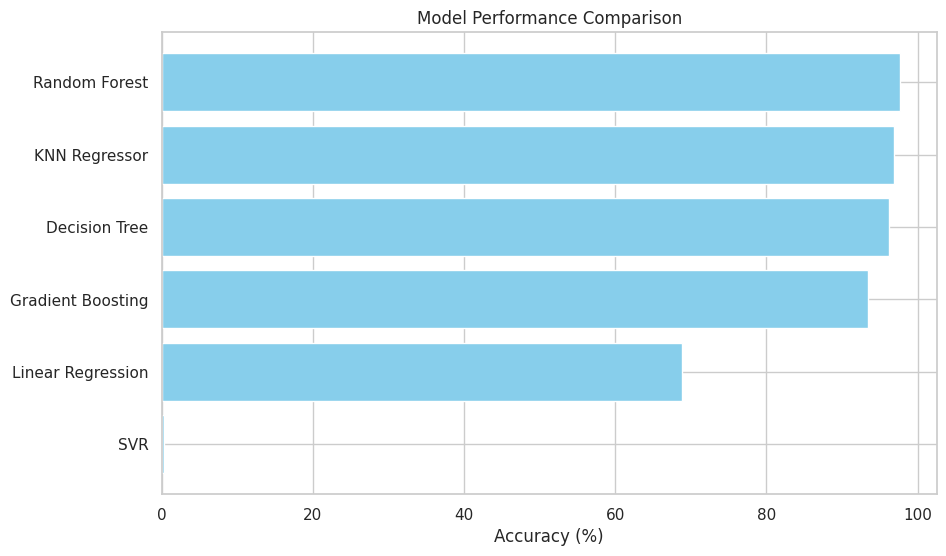

In [35]:
plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["Accuracy (%)"], color="skyblue")
plt.xlabel("Accuracy (%)")
plt.title("Model Performance Comparison")
plt.gca().invert_yaxis()  # Highest at top
plt.show()

## Thank you...pls upvote!!!!!